# Relaxed Poisson Distribution

Hadi's version: https://openreview.net/forum?id=ektPEcqGLb

In [1]:
# HIDE CODE


project_name = '_PoissonGradEstim'


import os, sys
from IPython.display import display

# tmp & extras dir (replace with your own paths)
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, project_name))
from utils.plotting import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

## Poisson args

You need to provide two things:

1. `log_rate`: log of firing rates (real numbers)

2. `temp`: non-negative temperature (`temp=0.0` corresponds to true Poisson)

3. `n_exp`: number of exponential draws (integer)

**Note:** See Algorithm 1 here: https://openreview.net/pdf?id=ektPEcqGLb
- `n_exp` is the same as the one shown in there
- `log_rate` is just **$\log\mathbf{\lambda}$**

In [2]:
from main.distributions import Poisson

### Make Poisson dists

In [3]:
# firing rates
lamb = torch.tensor([0.5, 1, 2, 8])

# number of exponential draws
n_exp = 200

# various temperatures
temperatures = [
    0.0, 0.01, 0.05, 0.1, 0.2, 0.3,
    0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0,
]

# keywords
kws = dict(
    log_rate=torch.log(lamb),
    clamp=None,
    n_exp=n_exp,
)

# dictionary of distributions (various temperatures)
dists = {
    t: Poisson(temp=t, **kws)
    for t in temperatures
}

### Draw samples

In [4]:
n_samples = int(1e5)

samples = collections.defaultdict(list)

for _ in tqdm(range(n_samples)):
    for t, dist in dists.items():
        samples[t].append(dist.rsample())

samples = {
    t: tonp(torch.stack(s).T)
    for t, s in samples.items()
}

100%|█████████████████████████████████| 100000/100000 [00:48<00:00, 2042.95it/s]


### Put data as dataframe

In [5]:
df = []

for t, samp in samples.items():
    for i, s in enumerate(samp):
        df.append({
            'Temperature': [t] * len(s),
            'lamb': [tonp(lamb)[i]] * len(s),
            'index': np.arange(len(s)),
            'sample': s,
        })

df = pd.DataFrame(merge_dicts(df))

len(df) / n_samples / len(lamb) / len(temperatures)

1.0

### Plot

In [6]:
muted = sns.color_palette('muted')
muted

[(0.2823529411764706, 0.47058823529411764, 0.8156862745098039),
 (0.9333333333333333, 0.5215686274509804, 0.2901960784313726),
 (0.41568627450980394, 0.8, 0.39215686274509803),
 (0.8392156862745098, 0.37254901960784315, 0.37254901960784315),
 (0.5843137254901961, 0.4235294117647059, 0.7058823529411765),
 (0.5490196078431373, 0.3803921568627451, 0.23529411764705882),
 (0.8627450980392157, 0.49411764705882355, 0.7529411764705882),
 (0.4745098039215686, 0.4745098039215686, 0.4745098039215686),
 (0.8352941176470589, 0.7333333333333333, 0.403921568627451),
 (0.5098039215686274, 0.7764705882352941, 0.8862745098039215)]

In [7]:
# color palette
pal_temp = {
    0.0: 'k', 
    0.01: muted[2],
    0.1: muted[3],
    1.0: muted[0],
}

# binning
upper = 5
n_bins = 50
width = upper / n_bins
bins = np.linspace(0, upper + width, n_bins + 3)
bins -= 3 * width / 2

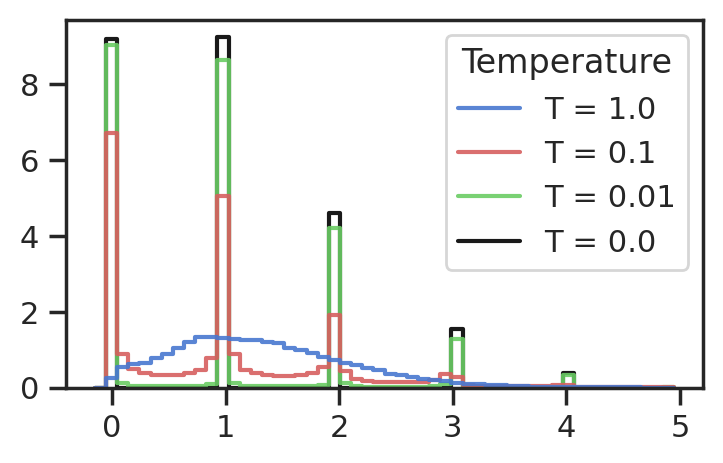

In [8]:
fig, ax = create_figure(1, 1, (3.5, 2.2), dpi=200)

d2p = df.loc[
    (df['lamb'] == 1.0) &
    (df['Temperature'].isin(pal_temp))
]

sns.histplot(
    d2p,
    x='sample',
    hue='Temperature',
    bins=bins,
    palette=pal_temp,
    alpha=0.9,
    stat='percent',
    element='step',
    fill=False,
    hue_order=[1.0, 0.1, 0.01, 0.0],
    ax=ax,
)
ax.set(xlabel='', ylabel='')

legend = ax.get_legend()
for text in legend.get_texts():
    text.set_text(f"T = {text.get_text()}")

# fig.savefig(pjoin(fig_dir, 'samples_hist.pdf'), **kws_fig)
plt.show()

## The effect of temperature on step function

In Algorithm 1, we have this step:

$\mathrm{indicator} \gets \text{sigmoid}\left(\frac{1 - \mathrm{times}}{\mathrm{temperature}}\right)$

This is just approximating the Heaviside step function. Let's see how it looks like for various nonzero temperatures.

### Define functions

In [9]:
def step_function(x):
    return np.where(x >= 0, 1, 0)

def sigmoid(x, t=1.0):
    return 1 / (1 + np.exp(-x / t))

### Make plots

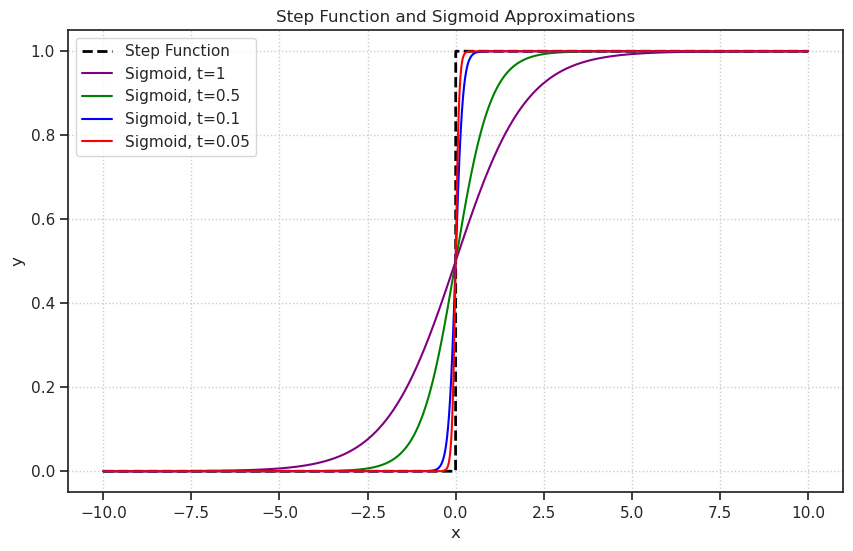

In [10]:
x = np.linspace(-10, 10, 10000)

plt.figure(figsize=(10, 6))
plt.plot(x, step_function(x), label='Step Function', color='black', lw=2, ls='--')

temperatures = [1, 0.5, 0.1, 0.05]
colors = ['purple', 'green', 'blue', 'red']
for t, c in zip(temperatures, colors):
    plt.plot(x, sigmoid(x, t), label=f'Sigmoid, t={t}', color=c)

plt.title('Step Function and Sigmoid Approximations')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

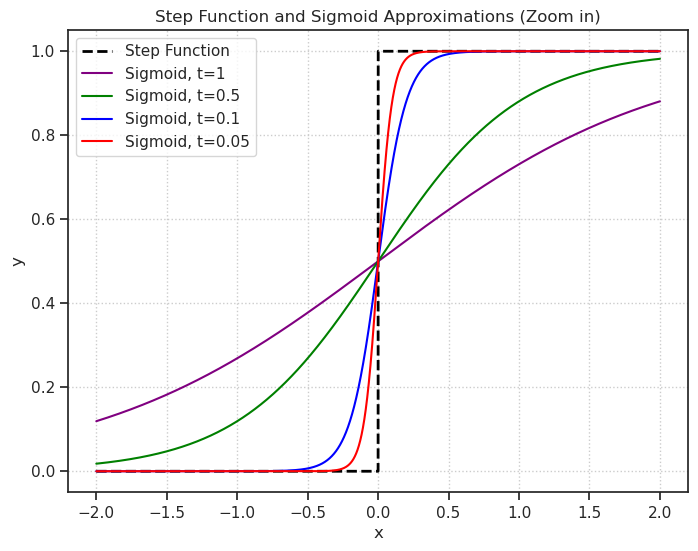

In [11]:
x = np.linspace(-2, 2, 10000)

plt.figure(figsize=(8, 6))
plt.plot(x, step_function(x), label='Step Function', color='black', lw=2, ls='--')

temperatures = [1, 0.5, 0.1, 0.05]
colors = ['purple', 'green', 'blue', 'red']
for t, c in zip(temperatures, colors):
    plt.plot(x, sigmoid(x, t), label=f'Sigmoid, t={t}', color=c)

plt.title('Step Function and Sigmoid Approximations (Zoom in)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

## Wait, was the old method faster?

In [28]:
from base.utils_model import *
dists.Distribution.set_default_validate_args(False)

In [29]:
class Poisson:
    def __init__(
            self,
            log_rate: torch.Tensor,
            temp: float = 0.0,
            clamp: float | None = None,
            n_exp: int | str = 'infer',
            n_exp_p: float = 1e-3,
    ):
        assert temp >= 0.0, f"must be non-neg: {temp}"
        self.temp = temp
        self.clamp = clamp
        # setup rate & exp dist
        if clamp is not None:
            log_rate = softclamp_upper(
                log_rate, clamp)
        eps = torch.finfo(torch.float32).eps
        self.rate = torch.exp(log_rate) + eps
        self._exp = dists.Exponential(self.rate)
        # compute n_exp
        if n_exp == 'infer':
            max_rate = self.rate.max().item()
            n_exp = compute_n_exp(max_rate, n_exp_p)
        self.n_exp = int(n_exp)

    def __repr__(self):
        parts = [
            f"rate: {self.rate.shape}",
            f"temp: {self.temp}",
            f"n_exp: {self.n_exp}",
        ]
        return f"Poisson({', '.join(parts)})"

    @property
    def mean(self):
        return self.rate

    @property
    def variance(self):
        return self.rate

    # noinspection PyTypeChecker
    def rsample(self):
        if self.temp == 0.0:
            return self.sample()
        x = self._exp.rsample((self.n_exp,))   # inter-event times
        times = torch.cumsum(x, dim=0)         # arrival t of events
        indicator = torch.sigmoid(             # events within [0, 1]
            (1 - times) / self.temp)
        z = indicator.sum(0).float()           # event counts
        return z

    def rsample_old(self, hard: bool = False):
        x = self._exp.rsample((self.n_exp,))  # inter-event times
        times = torch.cumsum(x, dim=0)  # arrival times of events

        indicator = times < 1.0
        z_hard = indicator.sum(0).float()

        if self.temp > 0:
            indicator = torch.sigmoid(
                (1.0 - times) / self.temp)
            z = indicator.sum(0).float()
        else:
            z = z_hard

        if hard:
            return z + (z_hard - z).detach()
        return z

    @torch.no_grad()
    def sample(self):
        return torch.poisson(self.rate).float()

    def log_prob(self, samples: torch.Tensor):
        return (
            - self.rate
            - torch.lgamma(samples + 1)
            + samples * torch.log(self.rate)
        )


### Test: CPU

In [30]:
lamb = torch.tensor([0.5, 1, 2, 8])

pois = Poisson(
    log_rate=torch.log(lamb),
    n_exp=1000,
    temp=0.1,
)

In [31]:
%timeit pois.rsample()

99.3 µs ± 128 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [32]:
%timeit pois.rsample_old()

113 µs ± 96.8 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


### Test: GPU

In [33]:
pois = Poisson(
    log_rate=torch.log(lamb).cuda(),
    n_exp=1000,
    temp=0.1,
)

In [34]:
%timeit pois.rsample()

73.5 µs ± 7.64 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [35]:
%timeit pois.rsample_old()

84.3 µs ± 79.3 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


No, the new version is faster

## Apporox density

Running simulations...

100%|█████████████████████████████████████████████| 3/3 [00:00<00:00, 21.53it/s]


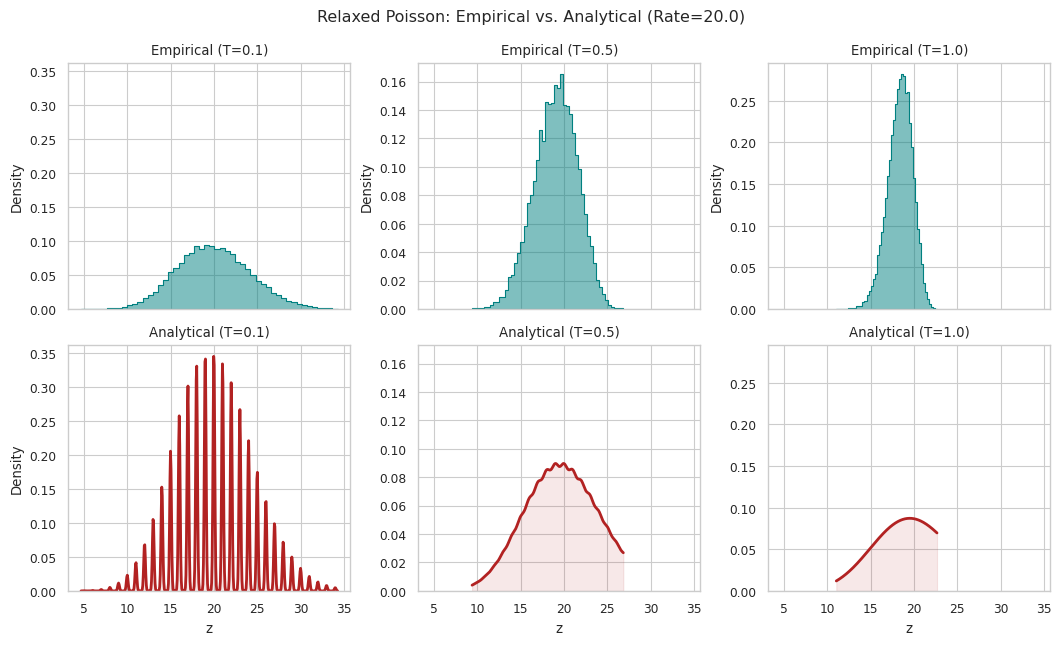

In [22]:
import torch
import torch.nn.functional as F
from torch import distributions as dists
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import scipy.stats as sp_stats  # Needed for compute_n_exp

# --- 1. Your Poisson Class & Helpers ---
def compute_n_exp(rate: float, p: float = 1e-6):
    assert rate > 0.0, f"must be positive, got: {rate}"
    pois = sp_stats.poisson(rate)
    n_exp = pois.ppf(1.0 - p)
    return int(n_exp)

def softclamp_upper(x: torch.Tensor, c: float):
    return c - F.softplus(c - x)

class Poisson:
    def __init__(self, log_rate: torch.Tensor, temp: float = 0.0, clamp=None, n_exp='infer', n_exp_p=1e-3):
        self.temp = temp
        if clamp is not None:
            log_rate = softclamp_upper(log_rate, clamp)
        eps = torch.finfo(torch.float32).eps
        self.rate = torch.exp(log_rate) + eps
        self._exp = dists.Exponential(self.rate)
        
        if n_exp == 'infer':
            max_rate = self.rate.max().item()
            n_exp = compute_n_exp(max_rate, n_exp_p)
        self.n_exp = int(n_exp)

    def rsample(self):
        if self.temp == 0.0: return self.sample()
        x = self._exp.rsample((self.n_exp,))   
        times = torch.cumsum(x, dim=0)         
        indicator = torch.sigmoid((1 - times) / self.temp)
        z = indicator.sum(0).float()           
        return z

    @torch.no_grad()
    def sample(self):
        return torch.poisson(self.rate).float()

# --- 2. The Analytical Approximation (Poisson-Logistic Mixture) ---
def log_prob_mixture(z, rate, temp, margin=10):
    """
    Computes log_prob using a Poisson-Logistic Mixture approximation.
    p(z) ~ Sum_k Poisson(k|rate) * Logistic(z|loc=k, scale=temp)
    """
    # Ensure inputs are tensors
    if not isinstance(z, torch.Tensor): z = torch.tensor(z)
    if not isinstance(rate, torch.Tensor): rate = torch.tensor(rate)
    
    # 1. Define the range of k values to sum over relative to z
    # shifts: [M]
    shifts = torch.arange(-margin, margin + 1, device=z.device)
    
    # Expand z to [1, ...] to broadcast with shifts [M, ...]
    z_expanded = z.unsqueeze(0) 
    
    # k_centers: [M, ...]
    # We broaden dimensions of shifts to match z_expanded's rank
    shifts_view = shifts.view(-1, *([1] * z.dim()))
    k_centers = z_expanded.floor() + shifts_view
    
    # 2. Compute Log-Weights (Poisson PMF)
    mask_valid = k_centers >= 0
    k_safe = k_centers.clamp(min=0)
    
    # Handle rate broadcasting. If rate is scalar, it works automatically.
    # If rate matches z shape, we unsqueeze it to match z_expanded.
    rate_expanded = rate.unsqueeze(0) if rate.dim() == z.dim() else rate
    
    log_weights = (
        k_safe * torch.log(rate_expanded) 
        - rate_expanded 
        - torch.lgamma(k_safe + 1)
    )
    
    # Mask invalid k (k < 0)
    log_weights = torch.where(mask_valid, log_weights, torch.tensor(-float('inf'), device=z.device))
    
    # 3. Compute Log-Kernels (Logistic PDF)
    # y = (z - k) / temp
    diff = z_expanded - k_centers
    y = diff / temp
    
    # Logistic Log PDF: -log(s) - y - 2*softplus(-y)
    log_kernels = -np.log(temp) - y - 2.0 * F.softplus(-y)
    
    # 4. Combine and Sum over the mixture dimension (dim 0)
    total_log_prob = torch.logsumexp(log_weights + log_kernels, dim=0)
    
    return total_log_prob

# --- 3. Plotting Code ---
lamb = torch.tensor([20.0]) 
temperatures = [0.1, 0.5, 1.0] 
n_samples = 20000

# Setup Plot: Shared Y-axis for columns
fig, axes = plt.subplots(nrows=2, ncols=len(temperatures), 
                         figsize=(3.5 * len(temperatures), 6), 
                         sharey='col', sharex=True, constrained_layout=True)

print("Running simulations...")
for col_idx, temp in enumerate(tqdm(temperatures)):
    # --- A. Empirical Sampling ---
    # Use batching for speed
    dist_batch = Poisson(torch.log(lamb.expand(1000)), temp=temp)
    batch_samples = [dist_batch.rsample() for _ in range(n_samples // 1000)]
    s = torch.stack(batch_samples).flatten().numpy()
    
    # Plot Histogram (Row 0)
    ax_hist = axes[0, col_idx]
    sns.histplot(s, bins=50, stat='density', element='step', 
                 color='teal', alpha=0.5, ax=ax_hist, label='Empirical')
    ax_hist.set_title(f"Empirical (T={temp})")
    
    # --- B. Analytical Curve (Row 1) ---
    ax_theo = axes[1, col_idx]
    
    # Create grid for analytical PDF
    z_min, z_max = s.min(), s.max()
    z_grid = torch.linspace(z_min, z_max, 500)
    
    # Compute PDF
    log_probs = relaxed_poisson_log_prob(z_grid, lamb[0], temp, margin=10)
    pdf = torch.exp(log_probs).detach().cpu().numpy()
    
    # Plot Curve
    # FIX: pdf might be shape (1, 500), so we flatten it
    ax_theo.plot(z_grid.numpy(), pdf.flatten(), color='firebrick', lw=2, label='Mixture Approx')
    ax_theo.fill_between(z_grid.numpy(), pdf.flatten(), color='firebrick', alpha=0.1)
    ax_theo.set_title(f"Analytical (T={temp})")
    ax_theo.set_xlabel("z")

axes[0, 0].set_ylabel("Density")
axes[1, 0].set_ylabel("Density")
plt.suptitle(f"Relaxed Poisson: Empirical vs. Analytical (Rate={lamb.item()})", y=1.05)
plt.show()

In [21]:
import torch
import torch.nn.functional as F
import numpy as np

def relaxed_poisson_log_prob(z, rate, temp, margin=10):
    """
    Computes log_prob of the Relaxed Poisson using a Gaussian Mixture approximation.
    
    The density is modeled as:
        p(z) = sum_k Poisson(k|rate) * Normal(z | mean=k, std=temp)
    
    This smooths the singularities at integers while preserving the 
    correct probability mass and temperature dependence.
    
    Args:
        z: [B, K] Sampled relaxed counts.
        rate: [B, K] Poisson rate parameters (lambda).
        temp: float, the relaxation temperature (serves as Gaussian std).
        margin: int, number of neighbors to sum over (truncation for efficiency).
    """
    # Ensure inputs are tensors
    if not isinstance(z, torch.Tensor): z = torch.tensor(z)
    if not isinstance(rate, torch.Tensor): rate = torch.tensor(rate)
    
    # 1. Define the range of k values to sum over: [floor(z) - margin, ..., floor(z) + margin]
    # We use a window around z for efficiency, as the Gaussian probability vanishes far away.
    shifts = torch.arange(-margin, margin + 1, device=z.device)
    
    # Expand z to allow broadcasting with the shifts
    # z: [Batch, Dim] -> z_expanded: [1, Batch, Dim]
    z_expanded = z.unsqueeze(0)
    
    # k_centers: [2*margin+1, Batch, Dim]
    # The integer centers for the mixture components
    k_centers = z_expanded.floor() + shifts.view(-1, *([1] * z.dim()))
    
    # 2. Compute Log-Weights (Poisson PMF)
    # log P(k|lambda) = k*log(lam) - lam - lgamma(k+1)
    
    # Valid k must be >= 0. We mask invalid indices later.
    k_safe = k_centers.clamp(min=0)
    
    # Handle rate broadcasting
    rate_expanded = rate.unsqueeze(0) if rate.dim() == z.dim() else rate
    
    log_weights = (
        k_safe * torch.log(rate_expanded) 
        - rate_expanded 
        - torch.lgamma(k_safe + 1)
    )
    
    # Mask invalid k (k < 0) with -inf
    mask_valid = k_centers >= 0
    log_weights = torch.where(mask_valid, log_weights, torch.tensor(-float('inf'), device=z.device))
    
    # 3. Compute Log-Kernels (Gaussian PDF)
    # log N(z; k, temp) = -0.5 * ((z - k)/temp)^2 - log(temp) - 0.5 * log(2pi)
    
    diff = z_expanded - k_centers
    # The width of the kernel is set to 'temp'
    sigma = temp 
    
    log_kernels = -0.5 * (diff / sigma)**2 - np.log(sigma) - 0.5 * np.log(2 * np.pi)
    
    # 4. Combine and Sum (LogSumExp mixture)
    # log p(z) = LogSumExp( log_weight + log_kernel )
    total_log_prob = torch.logsumexp(log_weights + log_kernels, dim=0)
    
    return total_log_prob

In [23]:
import math
import torch
import torch.nn.functional as F
from torch import distributions as dists

dists.Distribution.set_default_validate_args(False)


def compute_n_exp(rate: float, p: float = 1e-6):
    assert rate > 0.0, f"must be positive, got: {rate}"
    pois = sp_stats.poisson(rate)
    n_exp = pois.ppf(1.0 - p)
    return int(n_exp)

def softclamp_upper(x: torch.Tensor, c: float):
    return c - F.softplus(c - x)


class Poisson:
    """
    - temp == 0: exact discrete Poisson with torch.poisson sampling and log pmf.
    - temp > 0: your relaxed rsample; log_prob approximated by saddlepoint on the
      infinite-process relaxed distribution:

        Z_tau = sum_{events} sigmoid((1 - T_i)/tau)

      with {T_i} the event times of a Poisson process of rate lambda.

    Notes:
    - The saddlepoint log_prob is a continuous log density (log pdf), not a log pmf.
    - It is intended as a mitigation: a usable, differentiable likelihood surrogate.
    """

    def __init__(
        self,
        log_rate: torch.Tensor,
        temp: float = 0.0,
        clamp: float | None = None,
        n_exp: int | str = "infer",
        n_exp_p: float = 1e-3,
        # new knobs for log_prob(temp>0)
        sp_n_quad: int = 256,
        sp_quad_power: float = 4.0,
        sp_newton_steps: int = 12,
        sp_step_clip: float = 5.0,
        sp_s_clip: float = 80.0,
        sp_eps: float = 1e-12,
    ):
        assert temp >= 0.0, f"must be non-neg: {temp}"
        self.temp = float(temp)
        self.clamp = clamp

        # knobs for saddlepoint log_prob
        self.sp_n_quad = int(sp_n_quad)
        self.sp_quad_power = float(sp_quad_power)
        self.sp_newton_steps = int(sp_newton_steps)
        self.sp_step_clip = float(sp_step_clip)
        self.sp_s_clip = float(sp_s_clip)
        self.sp_eps = float(sp_eps)

        # setup rate & exp dist
        if clamp is not None:
            log_rate = softclamp_upper(log_rate, clamp)

        eps = torch.finfo(torch.float32).eps
        self.rate = torch.exp(log_rate) + eps
        self._exp = dists.Exponential(self.rate)

        # compute n_exp for your finite sampler
        if n_exp == "infer":
            max_rate = self.rate.max().item()
            n_exp = compute_n_exp(max_rate, n_exp_p)
        self.n_exp = int(n_exp)

        # precompute quadrature grid for CGF integrals if temp > 0
        self._quad_y = None
        self._quad_w = None
        self._y0 = None
        if self.temp > 0.0:
            self._setup_cgf_quadrature()

    def __repr__(self):
        parts = [
            f"rate: {self.rate.shape}",
            f"temp: {self.temp}",
            f"n_exp: {self.n_exp}",
        ]
        return f"Poisson({', '.join(parts)})"

    @property
    def mean(self):
        return self.rate

    @property
    def variance(self):
        return self.rate

    def rsample(self):
        if self.temp == 0.0:
            return self.sample()
        x = self._exp.rsample((self.n_exp,))   # inter-event times
        times = torch.cumsum(x, dim=0)         # arrival times
        indicator = torch.sigmoid((1 - times) / self.temp)
        z = indicator.sum(0).float()
        return z

    @torch.no_grad()
    def sample(self):
        return torch.poisson(self.rate).float()

    def log_prob(self, samples: torch.Tensor):
        """
        API-compatible behavior:
        - temp == 0: discrete Poisson log pmf (exact).
        - temp > 0: relaxed continuous log pdf (saddlepoint approximation).
        """
        if self.temp == 0.0:
            return self._log_prob_poisson_pmf(samples)
        return self._log_prob_relaxed_saddlepoint(samples)

    def _log_prob_poisson_pmf(self, samples: torch.Tensor):
        # Your original code:
        return (-self.rate - torch.lgamma(samples + 1) + samples * torch.log(self.rate))

    # ----------------------------
    # Relaxed log_prob machinery
    # ----------------------------

    def _setup_cgf_quadrature(self):
        """
        CGF representation (infinite-process relaxed distribution):
            K(s) = log E[exp(s Z)] = lambda * tau * ∫_0^{y0} (exp(s y) - 1) / (y(1-y)) dy
        where y0 = sigmoid(1/tau).

        Numerics:
        - Use a change of variable that concentrates points near y0 (important when tau is small and y0 ~ 1).
          Let u in (0,1), y(u) = y0 * (1 - (1-u)^p), p > 1.
          Then dy = y0 * p * (1-u)^(p-1) du.

        - Midpoint rule on u is simple and stable; you can increase sp_n_quad if needed.
        """
        device = self.rate.device
        dtype = torch.float64  # do CGF numerics in float64 for stability

        tau = float(self.temp)
        y0 = torch.sigmoid(torch.tensor(1.0 / tau, device=device, dtype=dtype))
        self._y0 = y0  # scalar tensor

        N = self.sp_n_quad
        p = self.sp_quad_power

        # midpoint grid in u
        u = (torch.arange(N, device=device, dtype=dtype) + 0.5) / N  # (N,)
        # cluster near u=1 hence near y=y0
        y = y0 * (1.0 - (1.0 - u).pow(p))                            # (N,)
        dy_du = y0 * p * (1.0 - u).pow(p - 1.0)                      # (N,)
        w = dy_du * (1.0 / N)                                        # (N,)

        # store as float64; broadcast later
        self._quad_y = y
        self._quad_w = w

    def _cgf_K_Kp_Kpp(self, s: torch.Tensor):
        """
        Compute K(s), K'(s), K''(s) for each element of s (same shape as rate).
        Uses precomputed quadrature over y in (0, y0).

        Shapes:
        - s: [B, K] (or broadcastable)
        - returns K, Kp, Kpp: [B, K]
        """
        assert self.temp > 0.0
        assert self._quad_y is not None and self._quad_w is not None

        # cast to float64 for stability
        s64 = s.to(dtype=torch.float64)
        lam64 = self.rate.to(dtype=torch.float64)
        tau64 = torch.tensor(self.temp, device=s.device, dtype=torch.float64)

        y = self._quad_y[:, None, None]  # [N,1,1]
        w = self._quad_w[:, None, None]  # [N,1,1]

        # exp(s*y) and expm1(s*y) computed in float64
        sy = s64[None, :, :] * y

        exp_sy = torch.exp(sy)                 # [N,B,K]
        expm1_sy = torch.expm1(sy)             # [N,B,K]

        # K integrand: (exp(sy)-1) / (y(1-y))
        denom = y * (1.0 - y)                  # [N,1,1]
        K_int = (expm1_sy / denom)             # [N,B,K]

        # K'(s) integrand: exp(sy) / (1-y)
        Kp_int = exp_sy / (1.0 - y)

        # K''(s) integrand: y * exp(sy) / (1-y)
        Kpp_int = y * exp_sy / (1.0 - y)

        # integrate over y and multiply lambda*tau
        K = (lam64 * tau64) * torch.sum(w * K_int, dim=0)      # [B,K]
        Kp = (lam64 * tau64) * torch.sum(w * Kp_int, dim=0)    # [B,K]
        Kpp = (lam64 * tau64) * torch.sum(w * Kpp_int, dim=0)  # [B,K]

        return K, Kp, Kpp

    def _relaxed_moments(self):
        """
        Analytic mean/var implied by the same CGF (infinite-process relaxed dist).

        mu = lambda * tau * log(1/(1-y0))
        var = lambda * tau * (log(1/(1-y0)) - y0)
        """
        assert self.temp > 0.0
        lam64 = self.rate.to(dtype=torch.float64)
        tau64 = torch.tensor(self.temp, device=self.rate.device, dtype=torch.float64)
        y0 = self._y0  # float64 scalar tensor

        log_term = torch.log(1.0 / (1.0 - y0))
        mu = lam64 * tau64 * log_term
        var = lam64 * tau64 * (log_term - y0)
        return mu, var

    def _solve_saddlepoint_s(self, z: torch.Tensor):
        """
        Solve K'(s) = z for s using damped Newton steps (vectorized).

        z must be positive.
        """
        z64 = z.to(dtype=torch.float64)
        mu, var = self._relaxed_moments()

        # initial guess: s0 ~ (z - mu)/var (like Gaussian tilt)
        s = (z64 - mu) / (var + self.sp_eps)

        # clip initial s to reasonable range
        s = torch.clamp(s, -self.sp_s_clip, self.sp_s_clip)

        for _ in range(self.sp_newton_steps):
            _, Kp, Kpp = self._cgf_K_Kp_Kpp(s)

            # Newton step: s <- s - (Kp - z)/Kpp
            step = (Kp - z64) / (Kpp + self.sp_eps)

            # damp/clip step to avoid overshoot
            step = torch.clamp(step, -self.sp_step_clip, self.sp_step_clip)
            s = s - step

            # keep s in a safe numeric range
            s = torch.clamp(s, -self.sp_s_clip, self.sp_s_clip)

        return s

    def _log_prob_relaxed_saddlepoint(self, samples: torch.Tensor):
        """
        Saddlepoint approximation of continuous log pdf for relaxed distribution.

        log p(z) ≈ K(s*) - s* z - 0.5 log(2π K''(s*))
        where s* solves K'(s*) = z.
        """
        z = samples

        # For a continuous density, z must be > 0. If z <= 0, return -inf.
        neg_inf = torch.tensor(-float("inf"), device=z.device, dtype=z.dtype)
        valid = z > 0

        z_safe = torch.where(valid, z, torch.ones_like(z) * 1e-6)

        s_star = self._solve_saddlepoint_s(z_safe)
        K, _, Kpp = self._cgf_K_Kp_Kpp(s_star)

        z64 = z_safe.to(dtype=torch.float64)
        log_pdf64 = K - s_star * z64 - 0.5 * torch.log(2.0 * math.pi * (Kpp + self.sp_eps))

        log_pdf = log_pdf64.to(dtype=z.dtype)
        log_pdf = torch.where(valid, log_pdf, neg_inf)
        return log_pdf


In [25]:
import math
import torch
import matplotlib.pyplot as plt

# If your compute_n_exp uses SciPy, make sure that's available.
# Otherwise set n_exp manually in the Poisson constructor for this test.


@torch.no_grad()
def run_relaxed_poisson_diagnostics(
    lambdas=(0.2, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0),
    temps=(0.05, 0.1, 0.2, 0.5),
    n_samples=200_000,
    n_exp="infer",          # or an int like 256/512 if you want to test truncation sensitivity
    n_exp_p=1e-5,           # tighten if you want the finite sampler closer to the infinite-process surrogate
    device="cuda:0",
    seed=0,
):
    torch.manual_seed(seed)

    for tau in temps:
        for lam in lambdas:
            # Build a batch of size n_samples with K=1 so we can histogram easily.
            log_rate = torch.full((n_samples, 1), math.log(lam), device=device)

            dist = Poisson(
                log_rate=log_rate,
                temp=float(tau),
                n_exp=n_exp,
                n_exp_p=float(n_exp_p),
                # You can tune these if needed:
                sp_n_quad=256,
                sp_quad_power=4.0,
                sp_newton_steps=12,
            )

            # 1) Monte Carlo samples (relaxed)
            z = dist.rsample().squeeze(-1)  # [n_samples]

            # 2) Moment check: compare MC moments vs CGF-implied moments
            # (dist._relaxed_moments is float64 and shaped [n_samples,1], but lambda is constant)
            mu_theory, var_theory = dist._relaxed_moments()
            mu_theory = mu_theory[0, 0].item()
            var_theory = var_theory[0, 0].item()

            mu_mc = z.mean().item()
            var_mc = z.var(unbiased=True).item()

            print(f"(lambda={lam:>6.2f}, tau={tau:>5.2f}) "
                  f"MC mean={mu_mc:.4f}, theory mean={mu_theory:.4f} | "
                  f"MC var={var_mc:.4f}, theory var={var_theory:.4f} | "
                  f"n_exp={dist.n_exp}")

            # 3) Histogram vs predicted pdf curve
            # Choose plotting range from quantiles
            z_sorted = torch.sort(z).values
            lo = z_sorted[int(0.001 * n_samples)].item()
            hi = z_sorted[int(0.999 * n_samples)].item()

            # bin and compute histogram density
            n_bins = 120
            hist = torch.histc(z, bins=n_bins, min=lo, max=hi)
            bin_edges = torch.linspace(lo, hi, steps=n_bins + 1, device=device)
            bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
            bin_width = (hi - lo) / n_bins
            hist_density = (hist / (hist.sum() * bin_width)).cpu().numpy()
            centers_np = bin_centers.cpu().numpy()

            # evaluate model log pdf on bin centers
            # use a separate distribution with a smaller batch for speed
            grid_log_rate = torch.full((n_bins, 1), math.log(lam), device=device)
            dist_grid = Poisson(
                log_rate=grid_log_rate,
                temp=float(tau),
                n_exp=dist.n_exp,       # irrelevant for log_prob, but keep consistent
                sp_n_quad=256,
                sp_quad_power=4.0,
                sp_newton_steps=12,
            )
            logpdf = dist_grid.log_prob(bin_centers[:, None]).squeeze(-1)
            pdf = torch.exp(logpdf).cpu().numpy()

            # plot
            plt.figure(figsize=(6, 3))
            plt.title(f"Relaxed Poisson: lambda={lam}, tau={tau}, n_exp={dist.n_exp}")
            plt.plot(centers_np, hist_density, label="MC histogram (rsample)")
            plt.plot(centers_np, pdf, label="Saddlepoint pdf (log_prob)", linestyle="--")
            plt.xlabel("z")
            plt.ylabel("density")
            plt.legend()
            plt.tight_layout()
            plt.show()

(lambda=  0.20, tau= 0.05) MC mean=0.2000, theory mean=0.2000 | MC var=0.1899, theory var=0.1900 | n_exp=4

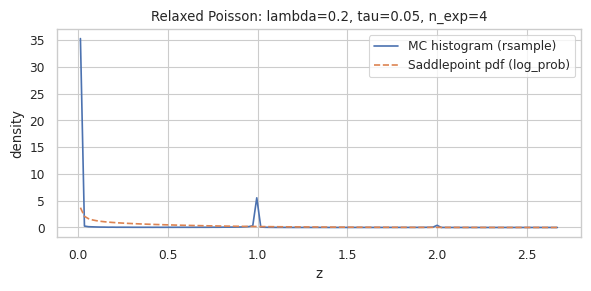

(lambda=  0.50, tau= 0.05) MC mean=0.5020, theory mean=0.5000 | MC var=0.4777, theory var=0.4750 | n_exp=6

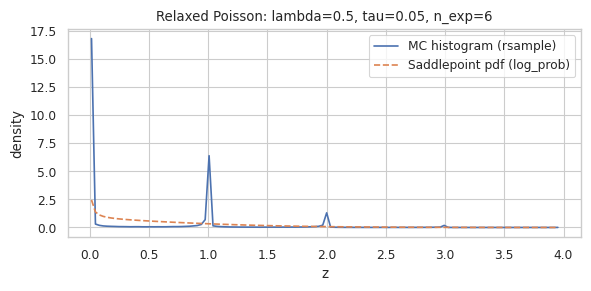

(lambda=  1.00, tau= 0.05) MC mean=0.9982, theory mean=1.0000 | MC var=0.9465, theory var=0.9500 | n_exp=8

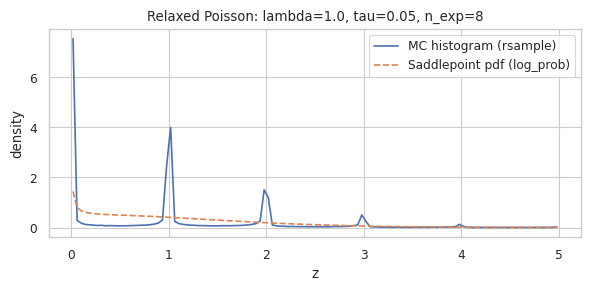

(lambda=  2.00, tau= 0.05) MC mean=1.9975, theory mean=2.0000 | MC var=1.8943, theory var=1.9000 | n_exp=10

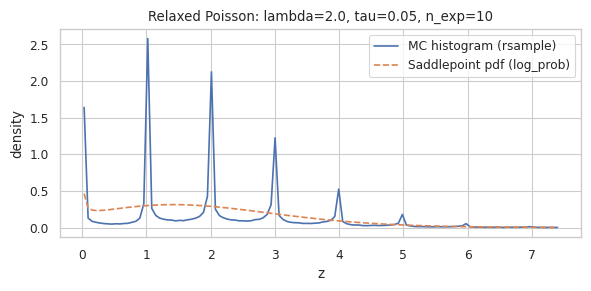

(lambda=  5.00, tau= 0.05) MC mean=5.0054, theory mean=5.0000 | MC var=4.7590, theory var=4.7500 | n_exp=17

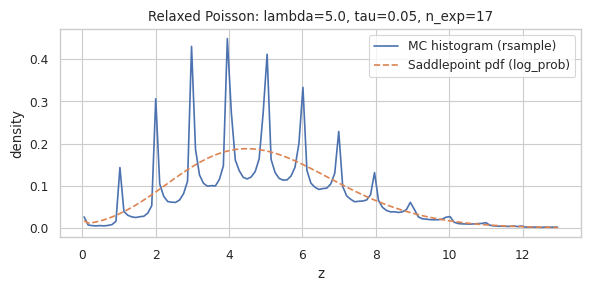

(lambda= 10.00, tau= 0.05) MC mean=9.9909, theory mean=10.0000 | MC var=9.4668, theory var=9.5000 | n_exp=26

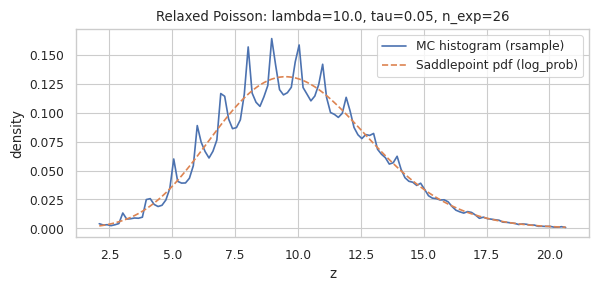

(lambda= 20.00, tau= 0.05) MC mean=19.9918, theory mean=20.0000 | MC var=18.9657, theory var=19.0000 | n_exp=42

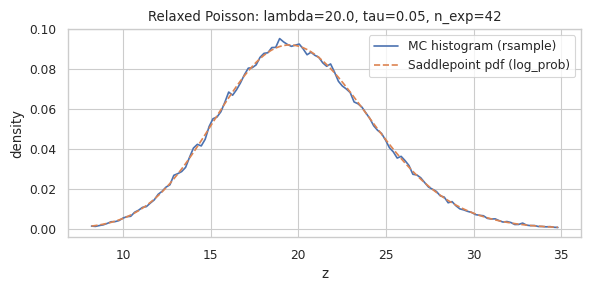

(lambda=  0.20, tau= 0.10) MC mean=0.1993, theory mean=0.2000 | MC var=0.1797, theory var=0.1800 | n_exp=4

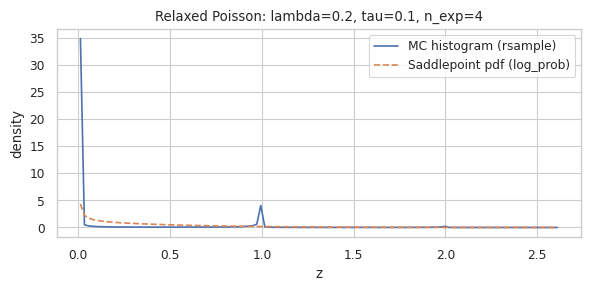

(lambda=  0.50, tau= 0.10) MC mean=0.4983, theory mean=0.5000 | MC var=0.4481, theory var=0.4500 | n_exp=6

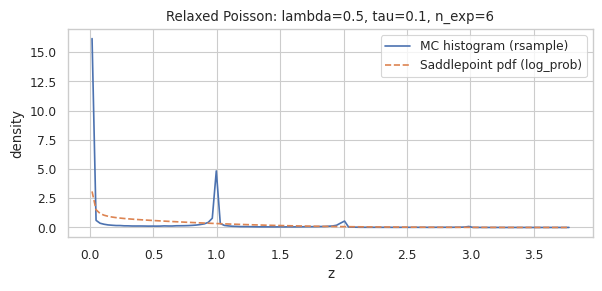

(lambda=  1.00, tau= 0.10) MC mean=1.0002, theory mean=1.0000 | MC var=0.8976, theory var=0.9000 | n_exp=8

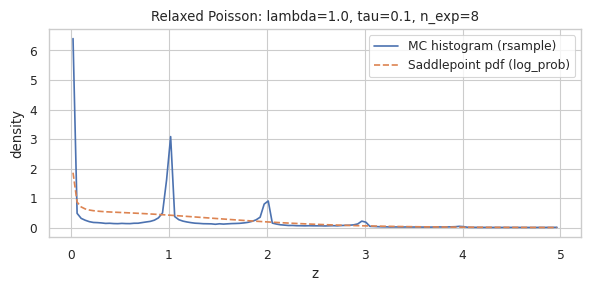

(lambda=  2.00, tau= 0.10) MC mean=1.9953, theory mean=2.0000 | MC var=1.8011, theory var=1.8000 | n_exp=10

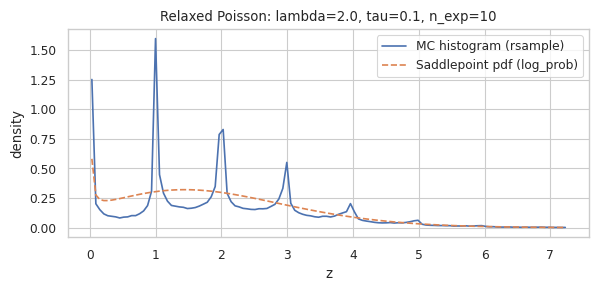

(lambda=  5.00, tau= 0.10) MC mean=5.0013, theory mean=5.0000 | MC var=4.4869, theory var=4.5000 | n_exp=17

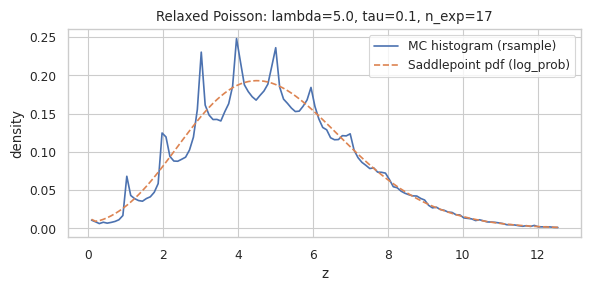

(lambda= 10.00, tau= 0.10) MC mean=9.9910, theory mean=10.0000 | MC var=9.0270, theory var=9.0001 | n_exp=26

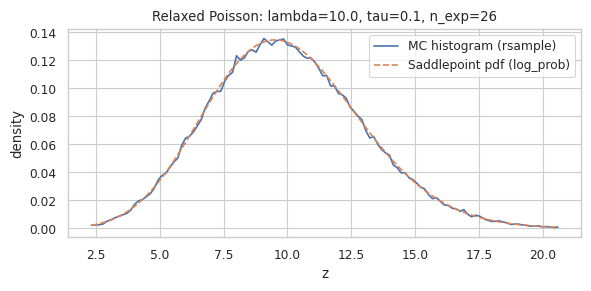

(lambda= 20.00, tau= 0.10) MC mean=20.0029, theory mean=20.0001 | MC var=17.9773, theory var=18.0002 | n_exp=42

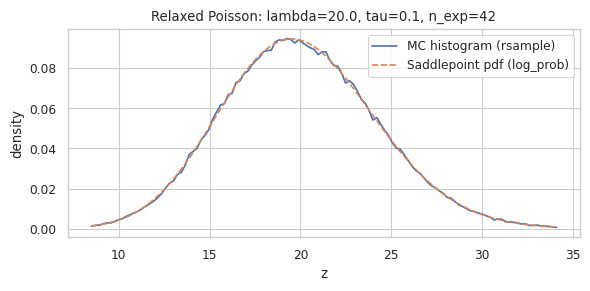

(lambda=  0.20, tau= 0.20) MC mean=0.2000, theory mean=0.2003 | MC var=0.1606, theory var=0.1605 | n_exp=4

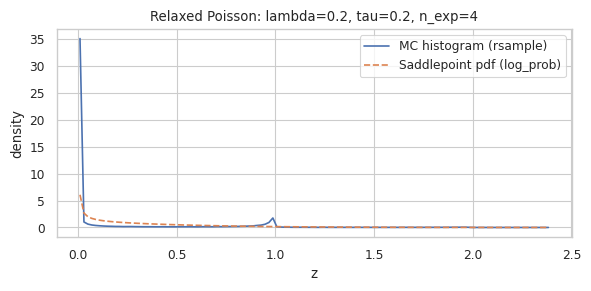

(lambda=  0.50, tau= 0.20) MC mean=0.5019, theory mean=0.5007 | MC var=0.4036, theory var=0.4013 | n_exp=6

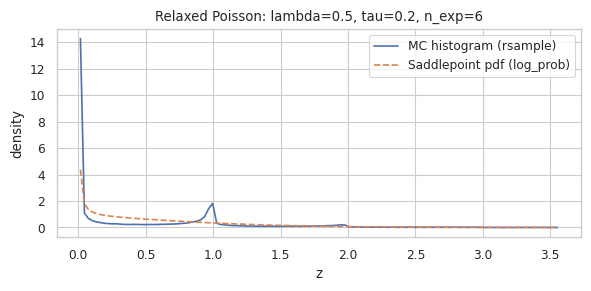

(lambda=  1.00, tau= 0.20) MC mean=1.0054, theory mean=1.0013 | MC var=0.8036, theory var=0.8027 | n_exp=8

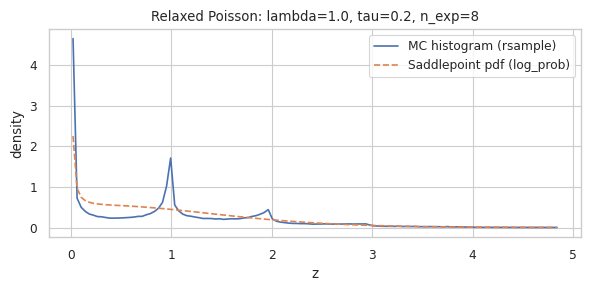

(lambda=  2.00, tau= 0.20) MC mean=2.0032, theory mean=2.0027 | MC var=1.6009, theory var=1.6054 | n_exp=10

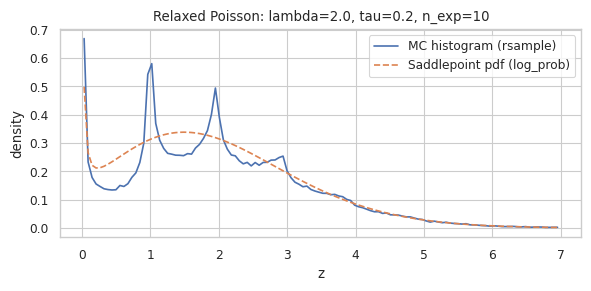

(lambda=  5.00, tau= 0.20) MC mean=5.0053, theory mean=5.0067 | MC var=4.0291, theory var=4.0134 | n_exp=17

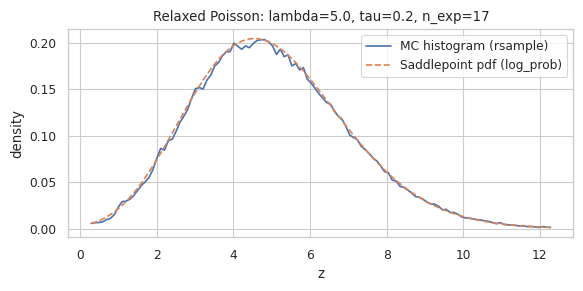

(lambda= 10.00, tau= 0.20) MC mean=9.9961, theory mean=10.0134 | MC var=7.9588, theory var=8.0268 | n_exp=26

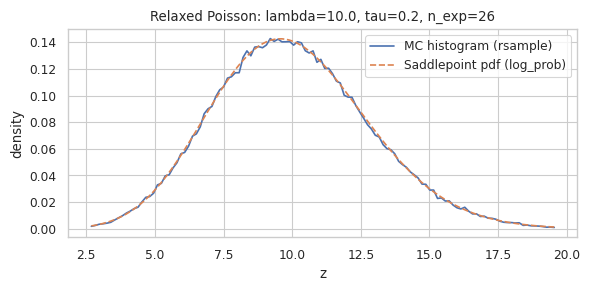

(lambda= 20.00, tau= 0.20) MC mean=19.9654, theory mean=20.0269 | MC var=15.5613, theory var=16.0536 | n_exp=42

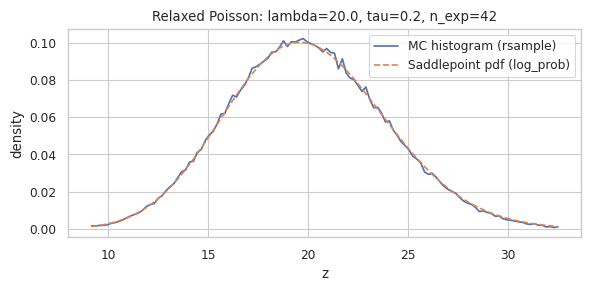

(lambda=  0.20, tau= 0.50) MC mean=0.2132, theory mean=0.2127 | MC var=0.1244, theory var=0.1246 | n_exp=4

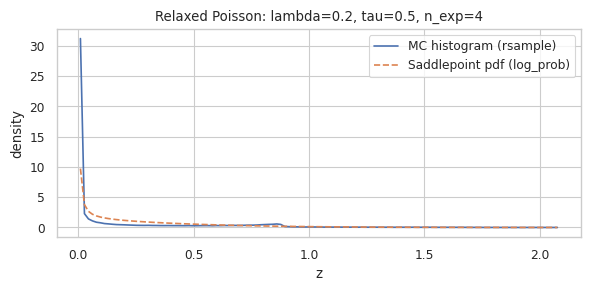

(lambda=  0.50, tau= 0.50) MC mean=0.5305, theory mean=0.5317 | MC var=0.3106, theory var=0.3115 | n_exp=6

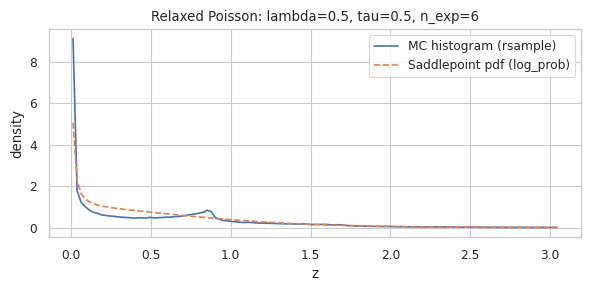

(lambda=  1.00, tau= 0.50) MC mean=1.0619, theory mean=1.0635 | MC var=0.6201, theory var=0.6231 | n_exp=8

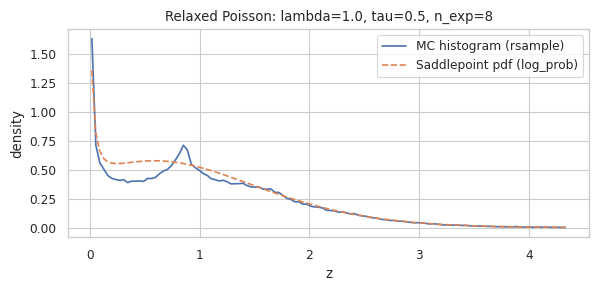

(lambda=  2.00, tau= 0.50) MC mean=2.1206, theory mean=2.1269 | MC var=1.2228, theory var=1.2461 | n_exp=10

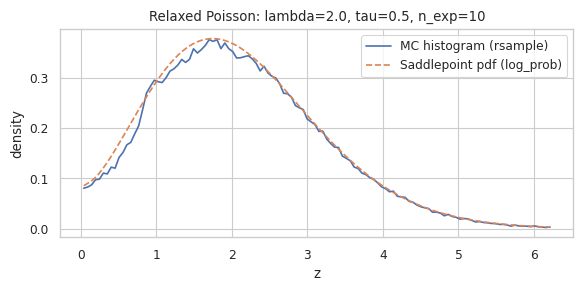

(lambda=  5.00, tau= 0.50) MC mean=5.2579, theory mean=5.3173 | MC var=2.8937, theory var=3.1153 | n_exp=17

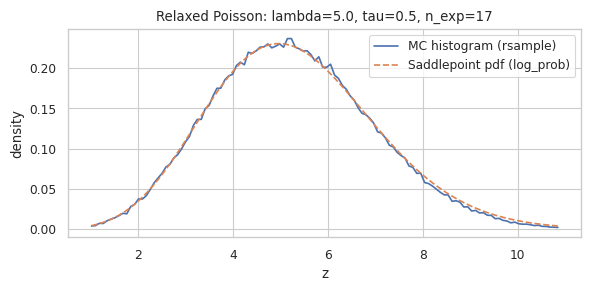

(lambda= 10.00, tau= 0.50) MC mean=10.3352, theory mean=10.6346 | MC var=5.1209, theory var=6.2307 | n_exp=26

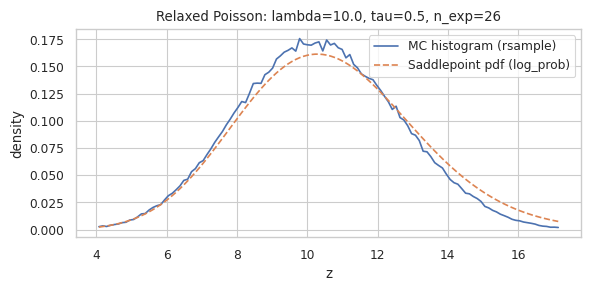

(lambda= 20.00, tau= 0.50) MC mean=20.0267, theory mean=21.2693 | MC var=8.4186, theory var=12.4613 | n_exp=42

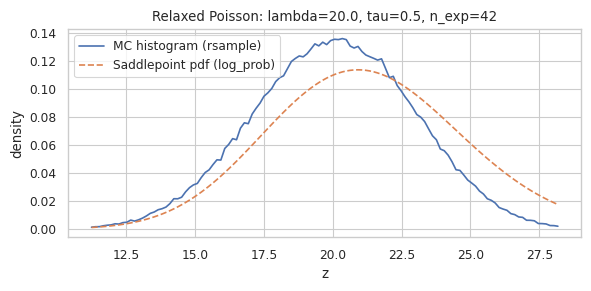

In [26]:
run_relaxed_poisson_diagnostics(
    lambdas=(0.2, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0),
    temps=(0.05, 0.1, 0.2, 0.5),
    n_samples=200_000,
    n_exp="infer",
    n_exp_p=1e-5,
    device="cpu",
    seed=0,
)

In [27]:
def exact_relaxed_poisson_log_prob(z, rate, temp, margin=1):
    """
    Computes the rigorous log_prob using Local Inversion (Jacobian method).
    Captures the U-shaped singularities at integers.
    """
    # 1. Setup
    if not isinstance(z, torch.Tensor): z = torch.tensor(z)
    if not isinstance(rate, torch.Tensor): rate = torch.tensor(rate)
    
    # Identify the dominant integer 'k'
    k_base = z.floor()
    
    # We sum densities over a small window of possible k's to account for overlap
    # (though usually only k_base and k_base-1 matter)
    shifts = torch.arange(-margin, margin + 1, device=z.device)
    z_expanded = z.unsqueeze(0) 
    k_centers = z_expanded.floor() + shifts.view(-1, *([1] * z.dim()))
    
    # 2. Fractional part 'u'
    # u is the value in (0, 1) relative to the integer k
    u = z_expanded - k_centers
    
    # Numerical stability: we cannot evaluate logit(0) or logit(1).
    # We clamp u strictly within (0, 1). The Jacobian correctly explodes here.
    eps = 1e-6
    u_clamped = u.clamp(min=eps, max=1-eps)
    
    # 3. Invert the transformation to find implied Time 't'
    # z = k + sigmoid((1 - t) / tau)  =>  t = 1 - tau * logit(u)
    logit_u = torch.logit(u_clamped)
    t_implied = 1.0 - temp * logit_u
    
    # 4. Compute the Jacobian term (The U-Shape)
    # log|dT/dz| = log(tau) - log(u) - log(1-u)
    log_jac = np.log(temp) - torch.log(u_clamped) - torch.log(1 - u_clamped)
    
    # 5. Compute Gamma Log-Prob of the implied time
    # T ~ Gamma(alpha=k+1, beta=rate)
    k_safe = k_centers.clamp(min=0)
    alpha = k_safe + 1
    
    # Handle rate broadcasting
    rate_expanded = rate.unsqueeze(0) if rate.dim() == z.dim() else rate
    
    # We use the lgamma-based definition of Gamma log_prob manually or via distribution
    # log P(t) = alpha*log(beta) - lgamma(alpha) + (alpha-1)*log(t) - beta*t
    # (PyTorch Gamma uses concentration=alpha, rate=beta)
    
    # Mask invalid paths:
    # 1. k < 0 (impossible)
    # 2. t <= 0 (causally impossible for this k)
    # 3. u not in (0, 1) (z not in the active window of this k)
    mask_valid = (k_centers >= 0) & (t_implied > 0) & (u > 0) & (u < 1)
    
    # Compute Gamma term
    gamma_term = (
        alpha * torch.log(rate_expanded) 
        - torch.lgamma(alpha) 
        + (alpha - 1) * torch.log(t_implied) 
        - rate_expanded * t_implied
    )
    
    # Combine terms
    log_prob_components = gamma_term + log_jac
    
    # Apply mask
    log_prob_components = torch.where(mask_valid, log_prob_components, torch.tensor(-float('inf'), device=z.device))
    
    # 6. Sum probabilities in log-space (Mixture of overlapping events)
    total_log_prob = torch.logsumexp(log_prob_components, dim=0)
    
    return total_log_prob

In [29]:
import torch
import torch.nn.functional as F
import numpy as np

def gaussian_mixture_log_prob(z, rate, temp, margin=10):
    """
    Computes log_prob using a Gaussian Mixture approximation.
    p(z) ~ Sum_k Poisson(k|rate) * Normal(z|loc=k, scale=temp)
    
    This smoothes the singularities of the exact density, resulting in 
    stable gradients and a visual match to empirical histograms.
    """
    # Ensure inputs are tensors
    if not isinstance(z, torch.Tensor): z = torch.tensor(z)
    if not isinstance(rate, torch.Tensor): rate = torch.tensor(rate)
    
    # 1. Define window of integers k to sum over
    # We sum over [floor(z)-margin, ..., floor(z)+margin]
    shifts = torch.arange(-margin, margin + 1, device=z.device)
    
    # Expand z for broadcasting: z_expanded [1, Batch, ...]
    z_expanded = z.unsqueeze(0)
    
    # k_centers: [2*margin+1, Batch, ...]
    shifts_view = shifts.view(-1, *([1] * z.dim()))
    k_centers = z_expanded.floor() + shifts_view
    
    # 2. Compute Log-Weights (Poisson PMF)
    # log P(k|lambda) = k*log(lam) - lam - lgamma(k+1)
    k_safe = k_centers.clamp(min=0)
    
    # Handle rate broadcasting
    rate_expanded = rate.unsqueeze(0) if rate.dim() == z.dim() else rate
    
    log_weights = (
        k_safe * torch.log(rate_expanded) 
        - rate_expanded 
        - torch.lgamma(k_safe + 1)
    )
    
    # Mask invalid k (k < 0) with -inf
    mask_valid = k_centers >= 0
    log_weights = torch.where(mask_valid, log_weights, torch.tensor(-float('inf'), device=z.device))
    
    # 3. Compute Log-Kernels (Gaussian PDF)
    # Using Gaussian kernel with std = temp
    # log N(z; k, temp) = -0.5 * ((z - k)/temp)^2 - log(temp) - 0.5 * log(2pi)
    
    diff = z_expanded - k_centers
    # We use temp as the standard deviation of the smoothing kernel
    sigma = temp 
    
    log_kernels = -0.5 * (diff / sigma)**2 - np.log(sigma) - 0.5 * np.log(2 * np.pi)
    
    # 4. Combine and Sum (LogSumExp)
    # log p(z) = LogSumExp( log_weight + log_kernel )
    total_log_prob = torch.logsumexp(log_weights + log_kernels, dim=0)
    
    return total_log_prob

In [34]:
import math
import torch
import torch.nn.functional as F
from torch import distributions as dists

dists.Distribution.set_default_validate_args(False)



def compute_n_exp(rate: float, p: float = 1e-6):
    assert rate > 0.0, f"must be positive, got: {rate}"
    pois = sp_stats.poisson(rate)
    n_exp = pois.ppf(1.0 - p)
    return int(n_exp)

def softclamp_upper(x: torch.Tensor, c: float):
    return c - F.softplus(c - x)



class _RelaxedPoissonFourierCache:
    """
    Precomputes A(omega) = tau * ∫_0^{y0} (exp(i*omega*y) - 1) / (y(1-y)) dy
    on an omega grid for a fixed temperature tau.

    Then for each element with rate lambda:
        K(i*omega) = lambda * A(omega)
        pdf(z) ≈ (1/pi) ∫_0^{omega_max} exp(lambda*A_re) * cos(lambda*A_im - omega*z) d omega
    """
    def __init__(
        self,
        tau: float,
        device: torch.device,
        n_omega: int = 2048,
        omega_max: float | None = None,
        omega_max_scale: float = 150.0,   # heuristic: omega_max = omega_max_scale / tau
        n_y_quad: int = 512,
        y_quad_power: float = 4.0,
        dtype: torch.dtype = torch.float64,
    ):
        assert tau > 0.0
        self.tau = float(tau)
        self.device = device
        self.dtype = dtype

        if omega_max is None:
            omega_max = omega_max_scale / self.tau

        self.n_omega = int(n_omega)
        self.omega_max = float(omega_max)

        self.n_y_quad = int(n_y_quad)
        self.y_quad_power = float(y_quad_power)

        self._build_omega_grid()
        self._build_y_quadrature()
        self._precompute_A()

    def _build_omega_grid(self):
        # omega in [0, omega_max], trapezoid weights
        w = torch.linspace(
            0.0, self.omega_max, steps=self.n_omega,
            device=self.device, dtype=self.dtype
        )
        dw = w[1] - w[0]
        trap = torch.ones_like(w)
        trap[0] = 0.5
        trap[-1] = 0.5

        self.omega = w                    # [M]
        self.dw = dw
        self.trap = trap                  # [M]

    def _build_y_quadrature(self):
        tau = torch.tensor(self.tau, device=self.device, dtype=self.dtype)
        y0 = torch.sigmoid(1.0 / tau)     # scalar
        self.y0 = y0

        N = self.n_y_quad
        p = self.y_quad_power

        u = (torch.arange(N, device=self.device, dtype=self.dtype) + 0.5) / N  # midpoint
        y = y0 * (1.0 - (1.0 - u).pow(p))
        dy_du = y0 * p * (1.0 - u).pow(p - 1.0)
        w = dy_du * (1.0 / N)

        self.y = y    # [N]
        self.wy = w   # [N]

    def _precompute_A(self):
        """
        Compute A_re(omega), A_im(omega) on omega grid.

        A(omega) = tau ∫ (e^{i omega y} - 1)/(y(1-y)) dy
        """
        tau = torch.tensor(self.tau, device=self.device, dtype=self.dtype)

        y = self.y[:, None]        # [N,1]
        wy = self.wy[:, None]      # [N,1]
        om = self.omega[None, :]   # [1,M]

        denom = y * (1.0 - y)      # [N,1]
        phase = om * y             # [N,M]

        # (cos + i sin) - 1
        num_re = torch.cos(phase) - 1.0
        num_im = torch.sin(phase)

        integrand_re = num_re / denom
        integrand_im = num_im / denom

        A_re = tau * torch.sum(wy * integrand_re, dim=0)  # [M]
        A_im = tau * torch.sum(wy * integrand_im, dim=0)  # [M]

        self.A_re = A_re
        self.A_im = A_im

    def log_pdf(self, z: torch.Tensor, lam: torch.Tensor, eps: float = 1e-30):
        """
        Vectorized log pdf for z with elementwise lambda (same shape), using CF inversion.

        z:  [...], lam: [...]
        returns: log p(z) with same shape
        """
        z64 = z.to(dtype=self.dtype)
        lam64 = lam.to(dtype=self.dtype)

        # Broadcast omega grid against z and lambda:
        # omega: [M,1,1,...], A_re/A_im: [M,1,1,...]
        # z/lam: [1,...]
        om = self.omega.view(-1, *([1] * z64.ndim))
        A_re = self.A_re.view(-1, *([1] * z64.ndim))
        A_im = self.A_im.view(-1, *([1] * z64.ndim))
        trap = self.trap.view(-1, *([1] * z64.ndim))

        # integrand = exp(lam*A_re) * cos(lam*A_im - omega*z)
        expo = torch.exp(lam64[None, ...] * A_re)
        arg = lam64[None, ...] * A_im - om * z64[None, ...]
        integrand = expo * torch.cos(arg)

        # trapezoid integration on [0, omega_max]
        integral = torch.sum(trap * integrand, dim=0) * self.dw

        pdf = integral / math.pi
        pdf = torch.clamp(pdf, min=eps)

        return torch.log(pdf).to(dtype=z.dtype)


class Poisson:
    _fourier_cache = {}  # keyed by (device, tau, n_omega, omega_max, omega_max_scale, n_y_quad, y_quad_power, dtype)

    def __init__(
        self,
        log_rate: torch.Tensor,
        temp: float = 0.0,
        clamp: float | None = None,
        n_exp: int | str = "infer",
        n_exp_p: float = 1e-3,

        # log_prob control
        log_prob_method: str = "fourier",   # "fourier" | "saddlepoint" | "none"
        # fourier settings
        fp_n_omega: int = 2048,
        fp_omega_max: float | None = None,
        fp_omega_max_scale: float = 150.0,
        fp_n_y_quad: int = 512,
        fp_y_quad_power: float = 4.0,
        fp_dtype: torch.dtype = torch.float64,
    ):
        assert temp >= 0.0, f"must be non-neg: {temp}"
        self.temp = float(temp)
        self.clamp = clamp
        self.log_prob_method = str(log_prob_method)

        # setup rate & exp dist
        if clamp is not None:
            log_rate = softclamp_upper(log_rate, clamp)

        eps = torch.finfo(torch.float32).eps
        self.rate = torch.exp(log_rate) + eps
        self._exp = dists.Exponential(self.rate)

        # compute n_exp for sampling
        if n_exp == "infer":
            max_rate = self.rate.max().item()
            n_exp = compute_n_exp(max_rate, n_exp_p)
        self.n_exp = int(n_exp)

        # build or reuse Fourier cache if needed
        self._fp_cache = None
        if self.temp > 0.0 and self.log_prob_method == "fourier":
            key = (
                str(self.rate.device),
                float(self.temp),
                int(fp_n_omega),
                None if fp_omega_max is None else float(fp_omega_max),
                float(fp_omega_max_scale),
                int(fp_n_y_quad),
                float(fp_y_quad_power),
                str(fp_dtype),
            )
            if key not in Poisson._fourier_cache:
                Poisson._fourier_cache[key] = _RelaxedPoissonFourierCache(
                    tau=self.temp,
                    device=self.rate.device,
                    n_omega=fp_n_omega,
                    omega_max=fp_omega_max,
                    omega_max_scale=fp_omega_max_scale,
                    n_y_quad=fp_n_y_quad,
                    y_quad_power=fp_y_quad_power,
                    dtype=fp_dtype,
                )
            self._fp_cache = Poisson._fourier_cache[key]

    def rsample(self):
        if self.temp == 0.0:
            return self.sample()
        x = self._exp.rsample((self.n_exp,))   # inter-event times
        times = torch.cumsum(x, dim=0)         # arrival times
        indicator = torch.sigmoid((1 - times) / self.temp)
        z = indicator.sum(0).float()
        return z

    @torch.no_grad()
    def sample(self):
        return torch.poisson(self.rate).float()

    def log_prob(self, samples: torch.Tensor):
        if self.temp == 0.0:
            return (-self.rate - torch.lgamma(samples + 1) + samples * torch.log(self.rate))

        if self.log_prob_method == "fourier":
            # continuous log pdf (approx, numeric inversion)
            # support is z > 0 in practice; clamp for safety
            z = torch.clamp(samples, min=1e-8)
            return self._fp_cache.log_pdf(z=z, lam=self.rate)

        if self.log_prob_method == "none":
            raise RuntimeError("log_prob undefined for temp>0 when log_prob_method='none'")

        raise ValueError(f"Unknown log_prob_method: {self.log_prob_method}")


In [35]:
import math
import torch
import matplotlib.pyplot as plt


@torch.no_grad()
def test_relaxed_poisson_fourier(
    lambdas=(0.2, 0.5, 1.0, 2.0, 5.0),
    temps=(0.01, 0.02, 0.05, 0.1, 0.2),
    n_samples=200_000,
    n_exp="infer",
    n_exp_p=1e-6,          # tighten truncation so rsample better matches infinite-process target
    device="cpu",
    seed=0,
):
    torch.manual_seed(seed)

    for tau in temps:
        for lam in lambdas:
            log_rate = torch.full((n_samples, 1), math.log(lam), device=device)

            dist = Poisson(
                log_rate=log_rate,
                temp=float(tau),
                n_exp=n_exp,
                n_exp_p=float(n_exp_p),
                log_prob_method="fourier",
                # Fourier resolution knobs; for small tau, bump omega grid
                fp_n_omega=4096 if tau <= 0.02 else 2048,
                fp_omega_max_scale=200.0,    # higher makes sharper peaks but costs more
                fp_n_y_quad=768 if tau <= 0.02 else 512,
                fp_y_quad_power=4.0,
            )

            z = dist.rsample().squeeze(-1)  # [n_samples]

            # choose plot window
            z_sorted = torch.sort(z).values
            lo = z_sorted[int(0.001 * n_samples)].item()
            hi = z_sorted[int(0.999 * n_samples)].item()

            # histogram density
            n_bins = 200
            hist = torch.histc(z, bins=n_bins, min=lo, max=hi)
            edges = torch.linspace(lo, hi, steps=n_bins + 1, device=device)
            centers = 0.5 * (edges[:-1] + edges[1:])
            bw = (hi - lo) / n_bins
            hist_density = (hist / (hist.sum() * bw)).cpu().numpy()
            centers_np = centers.cpu().numpy()

            # evaluate pdf on grid
            grid_log_rate = torch.full((n_bins, 1), math.log(lam), device=device)
            dist_grid = Poisson(
                log_rate=grid_log_rate,
                temp=float(tau),
                n_exp=dist.n_exp,
                log_prob_method="fourier",
                fp_n_omega=dist._fp_cache.n_omega,
                fp_omega_max=dist._fp_cache.omega_max,
                fp_n_y_quad=dist._fp_cache.n_y_quad,
                fp_y_quad_power=dist._fp_cache.y_quad_power,
            )
            logpdf = dist_grid.log_prob(centers[:, None]).squeeze(-1)
            pdf = torch.exp(logpdf).cpu().numpy()

            plt.figure()
            plt.title(f"lambda={lam}, tau={tau}, n_exp={dist.n_exp}")
            plt.plot(centers_np, hist_density, label="MC (rsample)")
            plt.plot(centers_np, pdf, linestyle="--", label="Fourier-inverted pdf")
            plt.xlabel("z")
            plt.ylabel("density")
            plt.legend()
            plt.tight_layout()
            plt.show()

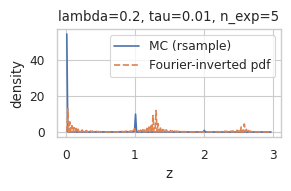

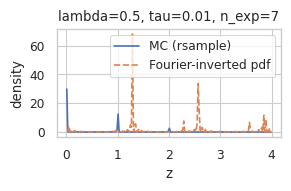

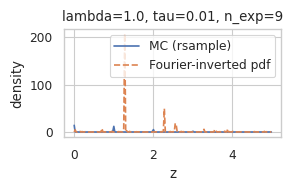

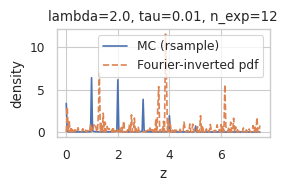

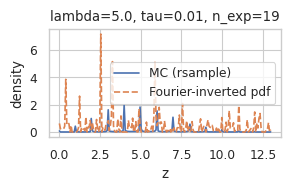

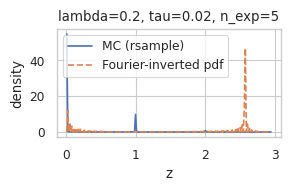

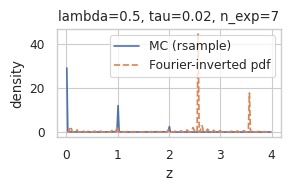

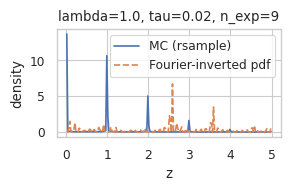

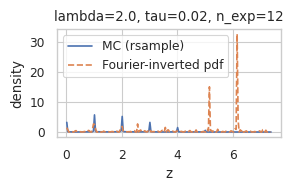

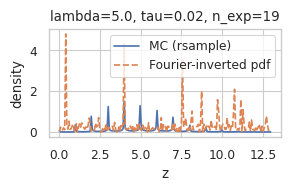

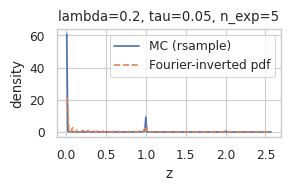

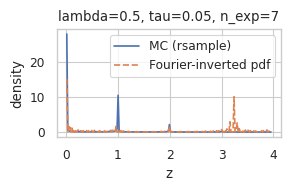

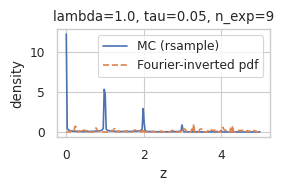

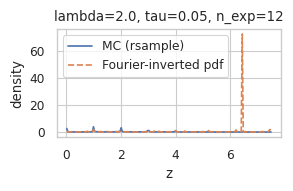

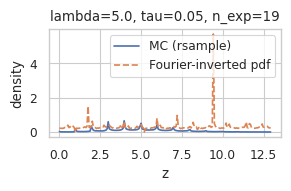

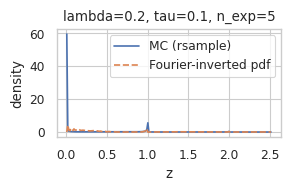

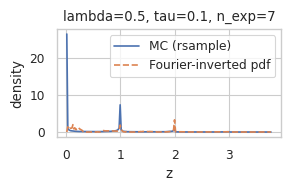

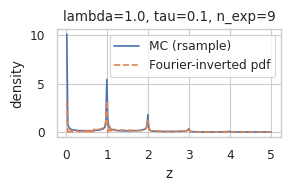

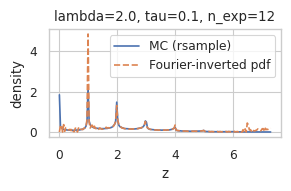

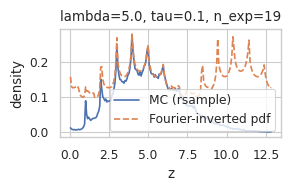

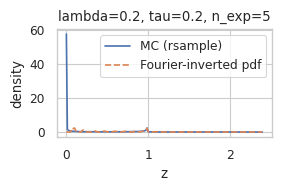

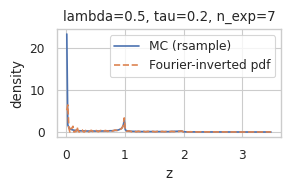

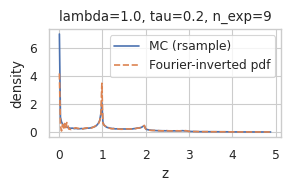

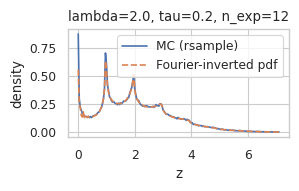

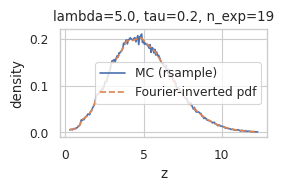

In [36]:
test_relaxed_poisson_fourier(
    lambdas=(0.2, 0.5, 1.0, 2.0, 5.0),
    temps=(0.01, 0.02, 0.05, 0.1, 0.2),
    n_samples=200_000,
    n_exp="infer",
    n_exp_p=1e-6,
    device="cpu",
    seed=0,
)

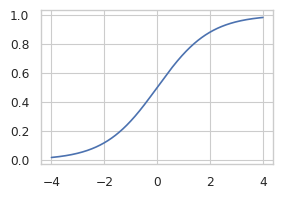

In [39]:
t = 0.1
x = torch.linspace(-4, 4, 1000)
y = torch.sigmoid(x)

plot(x, y)